# Entregable 4: Evaluación Robusta y Análisis de Trade-offs

| | |
|---|---|
| **Institución** | Instituto Tecnológico y de Estudios Superiores de Monterrey |
| **Curso** | TI3005B.101 — Trasformación digital de organizaciones de la sociedad civil |
| **Fecha** | 3 de marzo de 2026 |

**Autores:**

- Arturo Barrios Mendoza
- Lucio Arturo Reyes Castillo
- Mariana Balderrábano Aguilar
- Lizbeth Islas Becerril
- Maximiliano De La Cruz Lima
- Carlos Alberto Zamudio Velázquez
- Rafael Soto Padilla

---

Este notebook evalúa los resultados de la optimización multi-objetivo (NSGA-II) del simulador de robots de almacén,
compara con el baseline y analiza trade-offs explícitos entre las métricas de desempeño.

## Configuración del Algoritmo Evolutivo (NSGA-II)

La optimización multi-objetivo se realizó mediante el algoritmo **NSGA-II** (*Non-dominated Sorting Genetic Algorithm II*),
que explora simultáneamente múltiples configuraciones del almacén para encontrar el **frente de Pareto**: el conjunto de
soluciones donde no es posible mejorar un objetivo sin empeorar otro.

### Parámetros del algoritmo

| Parámetro | Valor |
|---|---|
| Población | 200 individuos |
| Generaciones | 30 |
| Ticks de evaluación | 10,000 por individuo |
| Área fija del almacén | 60,000 u² |
| Ventana de estrategia | 50 |

### Variables de decisión (rangos de búsqueda)

El algoritmo exploró combinaciones dentro de los siguientes rangos:

| Variable | Mínimo | Máximo | Descripción |
|---|---|---|---|
| `robots` | 5 | 70 | Cantidad de robots en el almacén |
| `width` | 100 | 400 | Ancho del almacén (px) |
| `stations` | 5 | 30 | Número de estaciones de carga/descarga |
| `orders_burst` | 0 | 1 | Modo de llegada de órdenes (0 = uniforme, 1 = ráfaga) |

> **Nota:** El área del almacén se mantuvo fija en 60,000 u², por lo que `height` se calcula automáticamente como `60000 / width`.
> Esto permite evaluar el efecto de la **proporción** del almacén sin confundir con cambios de escala.

### Objetivos de optimización

El algoritmo buscó optimizar **4 objetivos simultáneamente**:

| Objetivo | Métrica | Dirección |
|---|---|---|
| Deadlocks | `deadlocks` | Minimizar |
| Throughput | `throughput_per_1000_ticks` | Maximizar |
| Órdenes completadas | `completed_orders` | Maximizar |
| Tiempo promedio por orden | `avg_order_time_ticks` | Minimizar |

### Baseline de comparación

Como punto de referencia se ejecutó una simulación con la siguiente configuración fija:

| Parámetro | Valor |
|---|---|
| Robots | 20 |
| Ancho × Alto | 300 × 200 |
| Estaciones | 20 |
| Órdenes | 600 (modo ráfaga) |
| Semilla | 44 |

In [115]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)

ROOT = Path("..")  # repo root relative to notebooks/

SCENARIO_COLORS = {
    "burst": "#e74c3c",
    "nonburst": "#3498db",
    "baseline": "#8e44ad",
}

print("Setup completo.")

Setup completo.


In [116]:
# --- Carga de datos ---

# Baseline (corrido con nuestro codigo via `uv run moop --baseline`)
with open(ROOT / "outputs" / "baseline" / "metrics.json") as f:
    bl_raw = json.load(f)

bl_raw["orders_count"] = bl_raw.get("orders_count", bl_raw["total_orders"])
bl_raw["completion_pct"] = bl_raw["completed_orders"] / bl_raw["total_orders"] * 100

baseline = pd.DataFrame([bl_raw])

# Pareto front del MOOP
pareto = pd.read_csv(ROOT / "outputs" / "moop" / "pareto_front.csv")

print(f"Baseline: {len(baseline)} fila")
print(f"  Config: seed={bl_raw['seed']}, robots={bl_raw['robots']}, "
      f"grid={bl_raw['width']}x{bl_raw['height']}, stations={bl_raw['stations']}, "
      f"burst={bl_raw.get('orders_burst', 'N/A')}, ticks={bl_raw['final_tick']}")
print(f"  Resultados: throughput={bl_raw['throughput_per_1000_ticks']}, "
      f"completed={bl_raw['completed_orders']}/{bl_raw['total_orders']}, "
      f"deadlocks={bl_raw['deadlocks']}, contention={bl_raw['high_contention_events']}")
print(f"\nPareto: {len(pareto)} soluciones")
print(f"  Columnas: {list(pareto.columns)}")

Baseline: 1 fila
  Config: seed=44, robots=20, grid=300x200, stations=20, burst=True, ticks=10000
  Resultados: throughput=49.5, completed=495/600, deadlocks=0, contention=1127

Pareto: 62 soluciones
  Columnas: ['seed', 'robots', 'width', 'stations', 'orders_burst', 'height', 'orders_count', 'deadlocks', 'throughput_per_1000_ticks', 'completed_orders', 'avg_order_time_ticks', 'completion_pct', 'total_distance_cells', 'high_contention_events']


In [117]:
# --- Metricas derivadas ---

for df in [baseline, pareto]:
    df["throughput_norm"] = df["throughput_per_1000_ticks"] / df["robots"]
    df["distance_per_order"] = df["total_distance_cells"] / df["completed_orders"].replace(0, np.nan)
    df["contention_per_order"] = df["high_contention_events"] / df["completed_orders"].replace(0, np.nan)

print("Metricas derivadas calculadas: throughput_norm, distance_per_order, contention_per_order")

Metricas derivadas calculadas: throughput_norm, distance_per_order, contention_per_order


In [118]:
# --- Clasificacion de escenarios ---

def classify_scenario(row):
    if row["orders_burst"] == True or str(row["orders_burst"]).strip().lower() == "true":
        return "burst"
    return "nonburst"

pareto["scenario"] = pareto.apply(classify_scenario, axis=1)
SCENARIO_ORDER = sorted(pareto["scenario"].unique().tolist())

print("Distribucion de escenarios:")
print(pareto["scenario"].value_counts().to_string())
print(f"\nSCENARIO_ORDER = {SCENARIO_ORDER}")

Distribucion de escenarios:
scenario
burst       32
nonburst    30

SCENARIO_ORDER = ['burst', 'nonburst']


In [119]:
# --- Contexto: Baseline vs MOOP ---

bl_ticks = int(baseline["final_tick"].iloc[0])

context = pd.DataFrame({
    "Parametro": ["Seed", "Ticks", "Robots", "Grid", "Estaciones",
                  "Burst", "Pedidos", "Deadlocks", "Contencion"],
    "Baseline": [
        int(baseline["seed"].iloc[0]),
        bl_ticks,
        int(baseline["robots"].iloc[0]),
        f"{int(baseline['width'].iloc[0])}x{int(baseline['height'].iloc[0])}",
        int(baseline["stations"].iloc[0]),
        str(baseline["orders_burst"].iloc[0]),
        int(baseline["total_orders"].iloc[0]),
        f"{int(baseline['deadlocks'].iloc[0]):,}",
        f"{int(baseline['high_contention_events'].iloc[0]):,}",
    ],
    "MOOP (NSGA-II)": [
        int(pareto["seed"].iloc[0]),
        "10,000 (eval_ticks)",
        f"{int(pareto['robots'].min())}-{int(pareto['robots'].max())}",
        f"Area fija=60,000 ({int(pareto['width'].min())}-{int(pareto['width'].max())} ancho)",
        f"{int(pareto['stations'].min())}-{int(pareto['stations'].max())}",
        "Variable (True/False)",
        int(pareto["orders_count"].iloc[0]),
        f"{int(pareto['deadlocks'].min()):,}-{int(pareto['deadlocks'].max()):,}",
        f"{int(pareto['high_contention_events'].min()):,}-{int(pareto['high_contention_events'].max()):,}",
    ],
})

display(context.set_index("Parametro"))

bl_robots = int(baseline["robots"].iloc[0])
moop_robots_min = int(pareto["robots"].min())
moop_robots_max = int(pareto["robots"].max())
print(f"\nDiferencia principal: Baseline usa {bl_robots} robots vs MOOP {moop_robots_min}-{moop_robots_max} robots.")
print(f"Grid baseline: {int(baseline['width'].iloc[0])}x{int(baseline['height'].iloc[0])} vs MOOP: area fija 60,000 con aspecto variable.")
print(f"Se usan metricas normalizadas (por robot, por pedido) para comparaciones justas.")

,Baseline,MOOP (NSGA-II)
Parametro,,
Seed,44,44
Ticks,10000,"10,000 (eval_ticks)"
Robots,20,68-70
Grid,300x200,"Area fija=60,000 (278-385 ancho)"
Estaciones,20,5-28
Burst,True,Variable (True/False)
Pedidos,600,600
Deadlocks,0,"0-6,207"
Contencion,"1,127","709-84,667"



Diferencia principal: Baseline usa 20 robots vs MOOP 68-70 robots.
Grid baseline: 300x200 vs MOOP: area fija 60,000 con aspecto variable.
Se usan metricas normalizadas (por robot, por pedido) para comparaciones justas.


In [120]:
# --- Estadisticas descriptivas por escenario ---

metrics_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "total_distance_cells", "deadlocks",
    "throughput_norm", "distance_per_order", "contention_per_order",
]

desc = (
    pareto.groupby("scenario")[metrics_cols]
    .agg(["mean", "std", "min", "median", "max"])
)

with pd.option_context("display.max_columns", None, "display.max_rows", None,
                       "display.float_format", "{:.2f}".format):
    display(desc.T)

# Interpretacion
print("\n" + "=" * 70)
print("INTERPRETACION")
print("=" * 70)
for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    tp_std = s["throughput_per_1000_ticks"].std() if len(s) > 1 else 0
    cp_range = s["completion_pct"].max() - s["completion_pct"].min()
    print(f"\n  {scenario} ({len(s)} soluciones):")
    print(f"    Throughput: {s['throughput_per_1000_ticks'].mean():.1f} +/- {tp_std:.2f}")
    print(f"    Completud: {s['completion_pct'].mean():.1f}% (rango {cp_range:.1f}pp)")
    print(f"    Avg time: {s['avg_order_time_ticks'].mean():.0f} ticks")
    print(f"    Deadlocks: {s['deadlocks'].mean():.0f} (min={s['deadlocks'].min()}, max={s['deadlocks'].max()})")

scenario                             burst  nonburst
throughput_per_1000_ticks mean       58.58     59.56
                          std         0.41      0.21
                          min        57.70     59.30
                          median     58.60     59.55
                          max        59.20     60.00
completion_pct            mean       97.63     99.26
                          std         0.68      0.36
                          min        96.20     98.80
                          median     97.65     99.25
                          max        98.70    100.00
avg_order_time_ticks      mean      656.89   1962.55
                          std        14.53     23.18
                          min       645.15   1918.94
                          median    650.19   1961.46
                          max       713.60   2000.90
high_contention_events    mean    27393.09  28664.40
                          std     22065.56  13530.41
                          min       977.00    709.00
                          median  30813.00  29447.50
                          max     84667.00  45955.00
total_distance_cells      mean   257332.25 244824.47
                          std      1669.78   2454.33
                          min    255487.00 241563.00
                          median 258016.00 244661.50
                          max    260987.00 250249.00
deadlocks                 mean        0.00   5577.53
                          std         0.00   1062.15
                          min         0.00      0.00
                          median      0.00   5729.00
                          max         0.00   6207.00
throughput_norm           mean        0.84      0.85
                          std         0.01      0.01
                          min         0.82      0.85
                          median      0.84      0.85
                          max         0.87      0.87
distance_per_order        mean      439.31    411.07
                          std         3.12      4.82
                          min       435.24    403.77
                          median    438.63    410.41
                          max       451.97    422.01
contention_per_order      mean       47.01     48.21
                          std        38.08     22.86
                          min         1.66      1.18
                          median     52.76     49.45
                          max       146.74     77.50


INTERPRETACION

  burst (32 soluciones):
    Throughput: 58.6 +/- 0.41
    Completud: 97.6% (rango 2.5pp)
    Avg time: 657 ticks
    Deadlocks: 0 (min=0, max=0)

  nonburst (30 soluciones):
    Throughput: 59.6 +/- 0.21
    Completud: 99.3% (rango 1.2pp)
    Avg time: 1963 ticks
    Deadlocks: 5578 (min=0, max=6207)


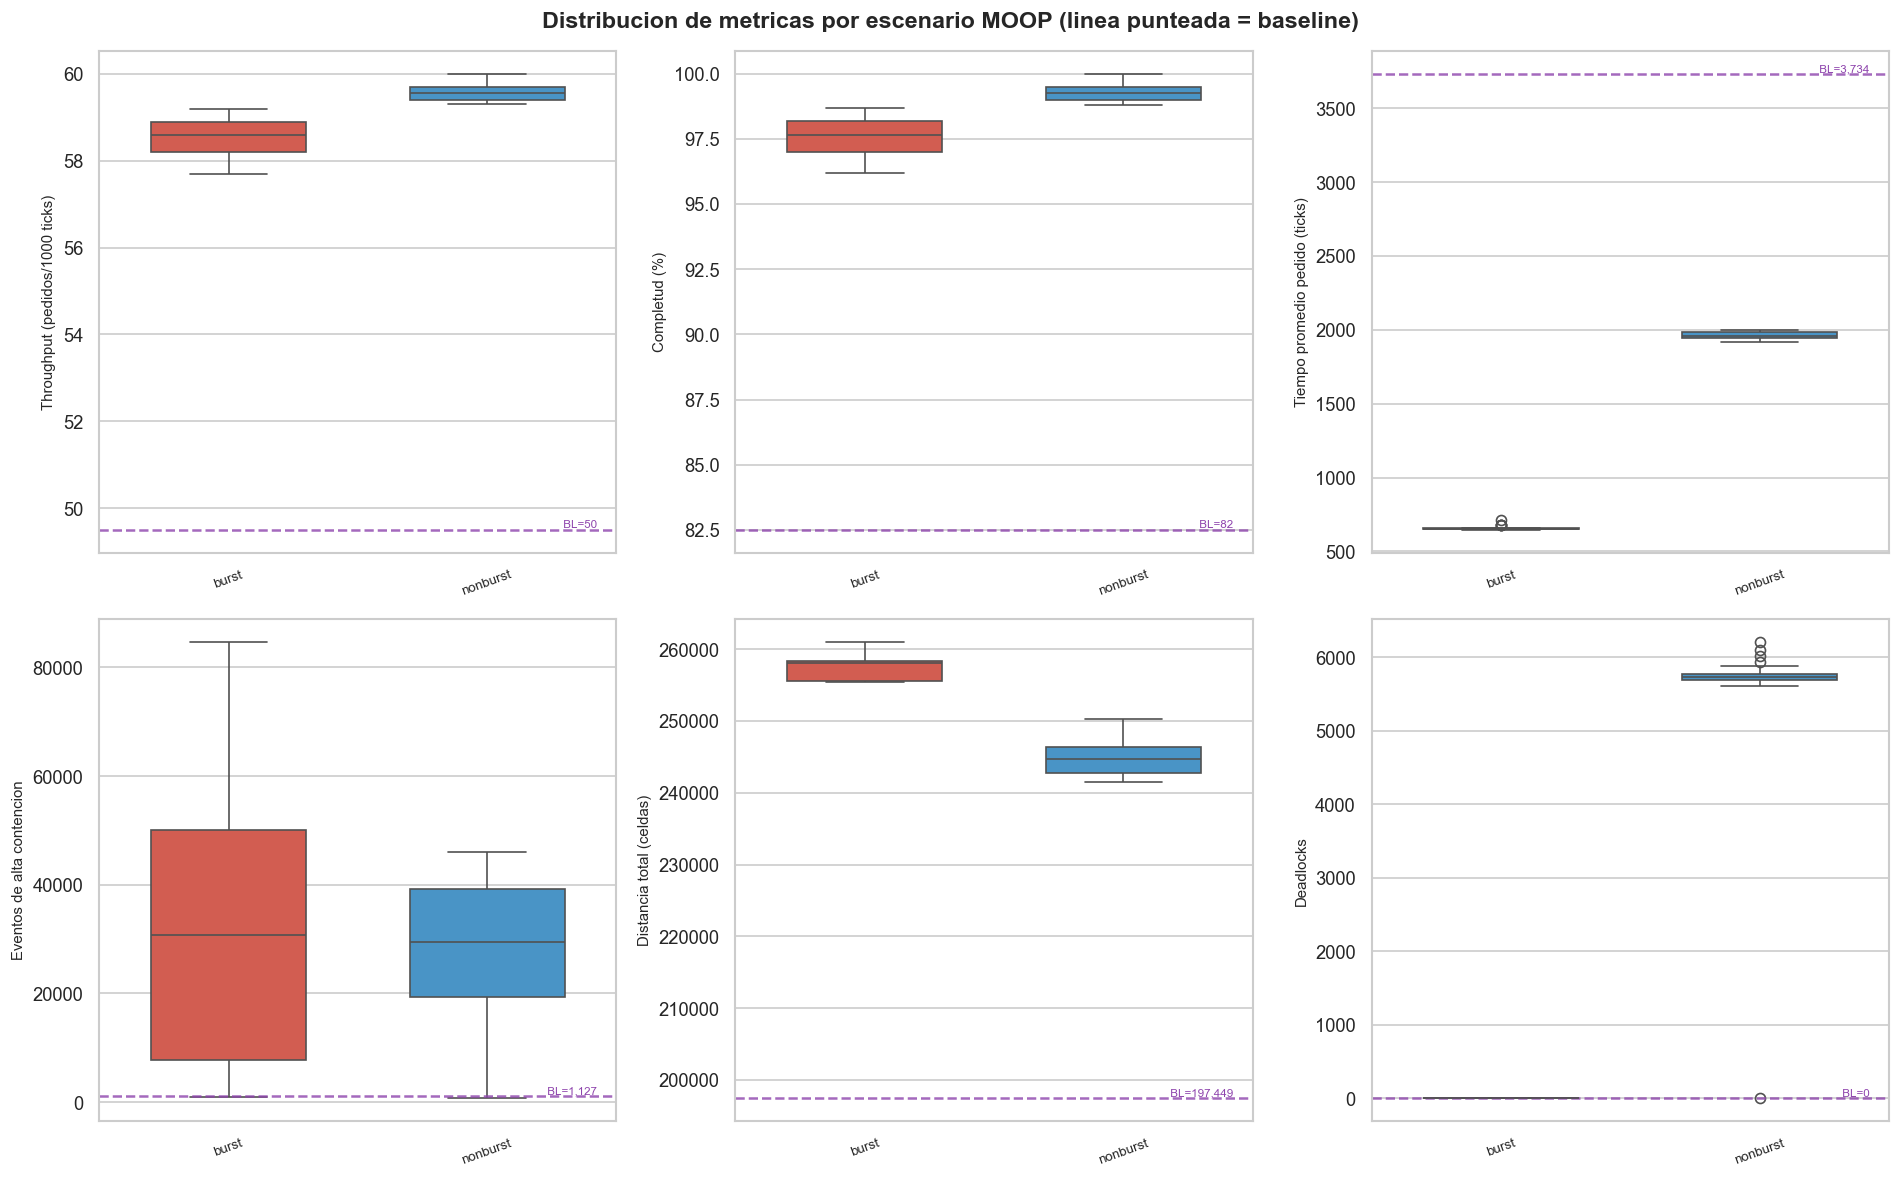

In [121]:
# --- Box plots por escenario con referencia baseline ---

plot_metrics = [
    ("throughput_per_1000_ticks", "Throughput (pedidos/1000 ticks)"),
    ("completion_pct", "Completud (%)"),
    ("avg_order_time_ticks", "Tiempo promedio pedido (ticks)"),
    ("high_contention_events", "Eventos de alta contencion"),
    ("total_distance_cells", "Distancia total (celdas)"),
    ("deadlocks", "Deadlocks"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribucion de metricas por escenario MOOP (linea punteada = baseline)",
             fontsize=14, fontweight="bold")

palette = {s: SCENARIO_COLORS.get(s, "#95a5a6") for s in SCENARIO_ORDER}

for ax, (col, label) in zip(axes.flat, plot_metrics):
    sns.boxplot(
        data=pareto, x="scenario", y=col, hue="scenario", order=SCENARIO_ORDER,
        palette=palette, ax=ax, width=0.6, legend=False,
    )
    if col in baseline.columns:
        bl_val = baseline[col].iloc[0]
        ax.axhline(bl_val, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5, alpha=0.8)
        ax.text(ax.get_xlim()[1] * 0.95, bl_val, f" BL={bl_val:,.0f}",
                va="bottom", ha="right", fontsize=7, color=SCENARIO_COLORS["baseline"])
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.tight_layout()
plt.show()

In [122]:
# --- Tabla comparativa: mean +/- std por escenario + baseline ---

compare_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "deadlocks", "total_distance_cells",
    "throughput_norm", "distance_per_order", "contention_per_order",
]

rows = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {"Escenario": scenario, "n": len(subset)}
    for col in compare_cols:
        m, s = subset[col].mean(), subset[col].std()
        row[col] = f"{m:.1f} +/- {s:.1f}" if s > 0.01 else f"{m:.1f}"
    rows.append(row)

bl_row = {"Escenario": "BASELINE", "n": 1}
for col in compare_cols:
    bl_row[col] = f"{baseline[col].iloc[0]:.1f}"
rows.append(bl_row)

compare_df = pd.DataFrame(rows).set_index("Escenario")
display(compare_df)

# Deltas porcentuales vs baseline (metricas normalizadas)
print("\n" + "=" * 70)
print("CAMBIO PORCENTUAL vs BASELINE (metricas normalizadas)")
print("=" * 70)

norm_cols = ["throughput_norm", "distance_per_order", "contention_per_order"]
norm_labels = ["Throughput/robot", "Distancia/pedido", "Contencion/pedido"]

delta_rows = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {"Escenario": scenario}
    for col, lbl in zip(norm_cols, norm_labels):
        bl_val = baseline[col].iloc[0]
        moop_val = subset[col].mean()
        delta = (moop_val - bl_val) / bl_val * 100 if bl_val != 0 else np.nan
        row[lbl] = f"{delta:+.1f}%"
    delta_rows.append(row)

display(pd.DataFrame(delta_rows).set_index("Escenario"))

,n,throughput_per_1000_ticks,completion_pct,avg_order_time_ticks,high_contention_events,deadlocks,total_distance_cells,throughput_norm,distance_per_order,contention_per_order
Escenario,,,,,,,,,,
burst,32,58.6 +/- 0.4,97.6 +/- 0.7,656.9 +/- 14.5,27393.1 +/- 22065.6,0.0,257332.2 +/- 1669.8,0.8,439.3 +/- 3.1,47.0 +/- 38.1
nonburst,30,59.6 +/- 0.2,99.3 +/- 0.4,1962.5 +/- 23.2,28664.4 +/- 13530.4,5577.5 +/- 1062.2,244824.5 +/- 2454.3,0.9,411.1 +/- 4.8,48.2 +/- 22.9
BASELINE,1,49.5,82.5,3734.5,1127.0,0.0,197449.0,2.5,398.9,2.3



CAMBIO PORCENTUAL vs BASELINE (metricas normalizadas)


,Throughput/robot,Distancia/pedido,Contencion/pedido
Escenario,,,
burst,-66.2%,+10.1%,+1964.9%
nonburst,-65.6%,+3.1%,+2017.3%


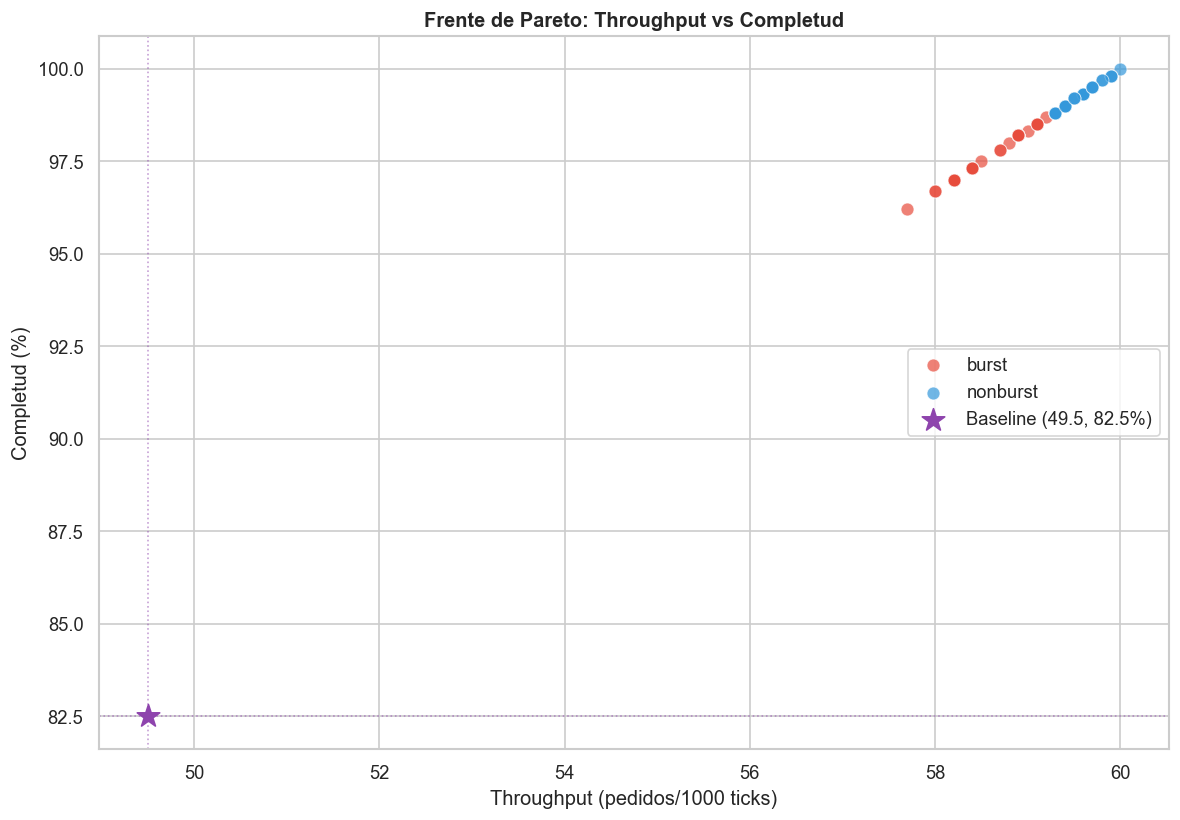


62/62 soluciones MOOP superan el throughput del baseline (49.5).
Baseline completud: 82.5%, MOOP rango: 96.2-100.0%


In [123]:
# --- Frente de Pareto: Throughput vs Completud ---

fig, ax = plt.subplots(figsize=(10, 7))

for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    ax.scatter(s["throughput_per_1000_ticks"], s["completion_pct"],
              c=SCENARIO_COLORS.get(scenario, "gray"), label=scenario, s=60, alpha=0.7,
              edgecolors="white", linewidth=0.5)

# Baseline
bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]
ax.scatter(bl_tp, bl_cp, c=SCENARIO_COLORS["baseline"], marker="*", s=200,
           zorder=5, label=f"Baseline ({bl_tp:.1f}, {bl_cp:.1f}%)")
ax.axvline(bl_tp, color=SCENARIO_COLORS["baseline"], ls=":", lw=1, alpha=0.5)
ax.axhline(bl_cp, color=SCENARIO_COLORS["baseline"], ls=":", lw=1, alpha=0.5)

ax.set_xlabel("Throughput (pedidos/1000 ticks)")
ax.set_ylabel("Completud (%)")
ax.set_title("Frente de Pareto: Throughput vs Completud", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

n_above = (pareto["throughput_per_1000_ticks"] > bl_tp).sum()
print(f"\n{n_above}/{len(pareto)} soluciones MOOP superan el throughput del baseline ({bl_tp:.1f}).")
print(f"Baseline completud: {bl_cp:.1f}%, MOOP rango: {pareto['completion_pct'].min():.1f}-{pareto['completion_pct'].max():.1f}%")

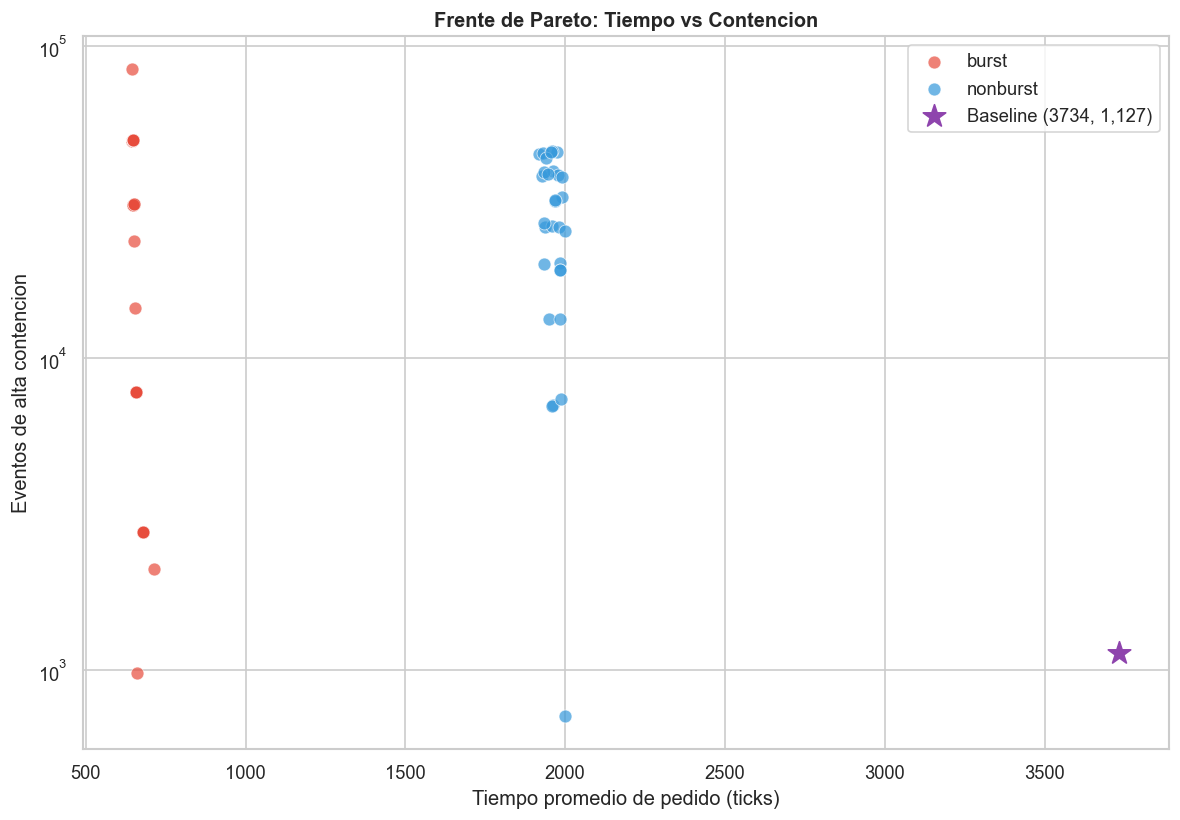

In [124]:
# --- Frente de Pareto: Tiempo vs Contencion ---

fig, ax = plt.subplots(figsize=(10, 7))

for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    ax.scatter(s["avg_order_time_ticks"], s["high_contention_events"],
              c=SCENARIO_COLORS.get(scenario, "gray"), label=scenario, s=60, alpha=0.7,
              edgecolors="white", linewidth=0.5)

bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_hc = baseline["high_contention_events"].iloc[0]
ax.scatter(bl_at, bl_hc, c=SCENARIO_COLORS["baseline"], marker="*", s=200,
           zorder=5, label=f"Baseline ({bl_at:.0f}, {bl_hc:,})")

ax.set_xlabel("Tiempo promedio de pedido (ticks)")
ax.set_ylabel("Eventos de alta contencion")
if pareto["high_contention_events"].max() / max(pareto["high_contention_events"].min(), 1) > 10:
    ax.set_yscale("log")
ax.set_title("Frente de Pareto: Tiempo vs Contencion", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

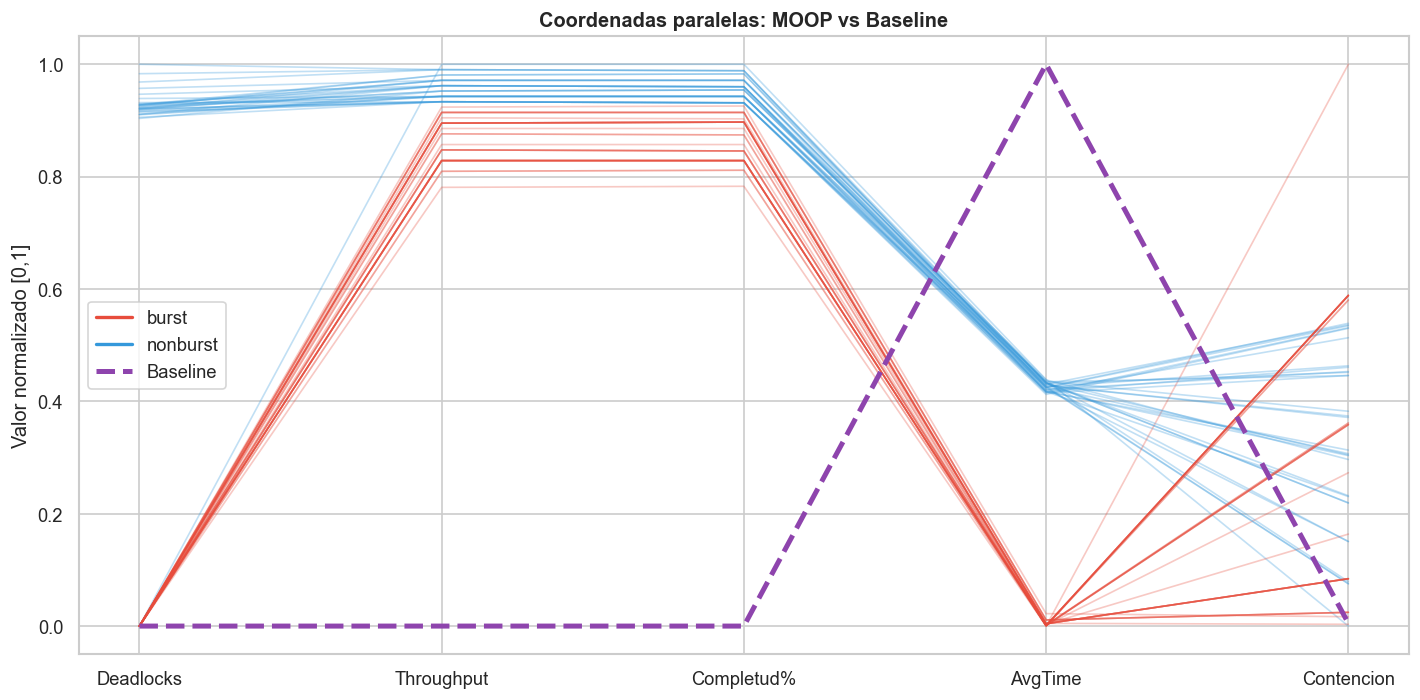

In [125]:
# --- Coordenadas paralelas ---

pc_cols = ["deadlocks", "throughput_per_1000_ticks", "completion_pct",
           "avg_order_time_ticks", "high_contention_events"]
pc_labels = ["Deadlocks", "Throughput", "Completud%", "AvgTime", "Contencion"]

# Normalize [0,1]
all_data = pd.concat([pareto[pc_cols], baseline[pc_cols]], ignore_index=True)
mins = all_data.min()
maxs = all_data.max()
rng = (maxs - mins).replace(0, 1)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(pc_cols))

for _, row in pareto.iterrows():
    vals = [(row[c] - mins[c]) / rng[c] for c in pc_cols]
    color = SCENARIO_COLORS.get(row["scenario"], "gray")
    ax.plot(x, vals, color=color, alpha=0.3, lw=1)

# Baseline
bl_vals = [(baseline[c].iloc[0] - mins[c]) / rng[c] for c in pc_cols]
ax.plot(x, bl_vals, color=SCENARIO_COLORS["baseline"], lw=3, ls="--",
        label="Baseline", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(pc_labels)
ax.set_ylabel("Valor normalizado [0,1]")
ax.set_title("Coordenadas paralelas: MOOP vs Baseline", fontweight="bold")

handles = [Line2D([0], [0], color=SCENARIO_COLORS[s], lw=2) for s in SCENARIO_ORDER]
handles.append(Line2D([0], [0], color=SCENARIO_COLORS["baseline"], lw=3, ls="--"))
ax.legend(handles, SCENARIO_ORDER + ["Baseline"])
plt.tight_layout()
plt.show()

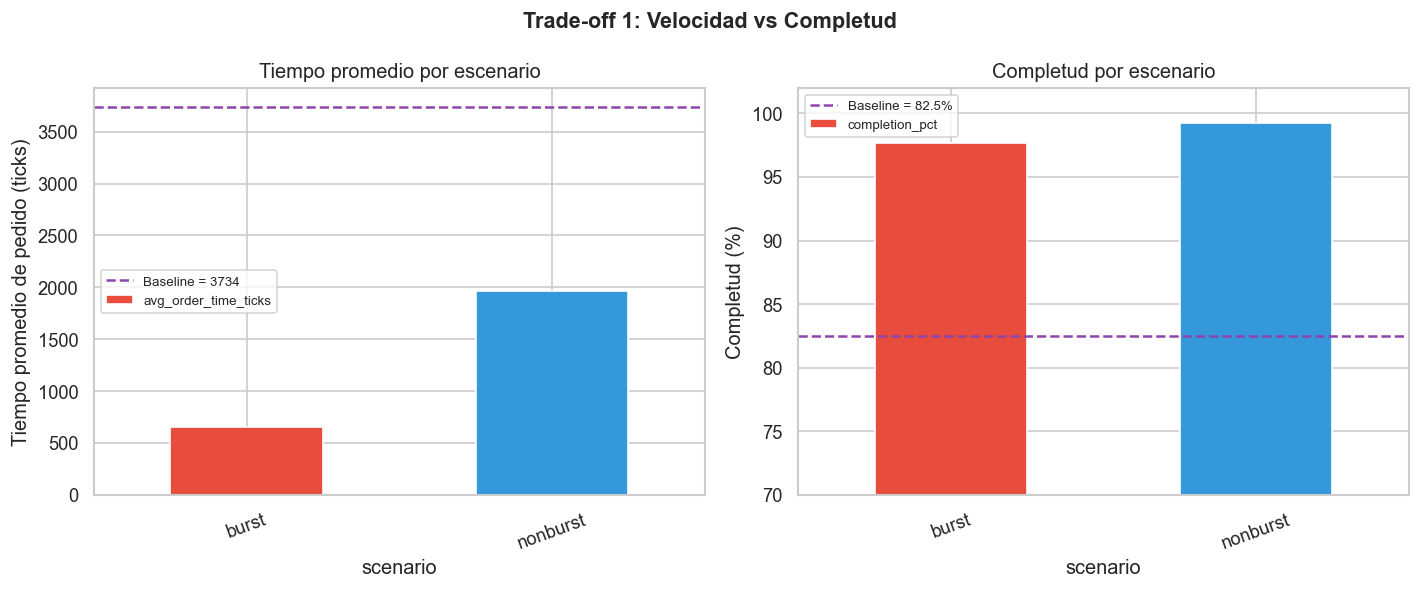

In [126]:
# --- Trade-off 1: Burst vs Completud ---

tradeoff1 = pareto.groupby("scenario")[["avg_order_time_ticks", "completion_pct"]].mean()
plot_scenarios = [s for s in ["burst", "nonburst"] if s in tradeoff1.index]
tradeoff1 = tradeoff1.loc[plot_scenarios]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = [SCENARIO_COLORS[s] for s in tradeoff1.index]
bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]

tradeoff1["avg_order_time_ticks"].plot.bar(ax=ax1, color=colors, edgecolor="white")
ax1.axhline(bl_at, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_at:.0f}")
ax1.set_ylabel("Tiempo promedio de pedido (ticks)")
ax1.set_title("Tiempo promedio por escenario")
ax1.tick_params(axis="x", rotation=20)
ax1.legend(fontsize=8)

tradeoff1["completion_pct"].plot.bar(ax=ax2, color=colors, edgecolor="white")
ax2.axhline(bl_cp, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_cp:.1f}%")
ax2.set_ylabel("Completud (%)")
ax2.set_title("Completud por escenario")
ax2.set_ylim(min(70, bl_cp - 5), 102)
ax2.tick_params(axis="x", rotation=20)
ax2.legend(fontsize=8)

fig.suptitle("Trade-off 1: Velocidad vs Completud", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [127]:
# --- Interpretacion Trade-off 1 ---

burst_t = tradeoff1.loc["burst", "avg_order_time_ticks"]
nb_scenarios = [s for s in ["nonburst"] if s in tradeoff1.index]
nb_t = tradeoff1.loc[nb_scenarios, "avg_order_time_ticks"].mean()
burst_cp = tradeoff1.loc["burst", "completion_pct"]
nb_cp = tradeoff1.loc[nb_scenarios, "completion_pct"].mean()
bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]

reduccion = (1 - burst_t / nb_t) * 100
perdida = nb_cp - burst_cp

print("=" * 70)
print("TRADE-OFF 1: Velocidad vs Completud")
print("=" * 70)
print(f"\n  Tiempo promedio de pedido:")
print(f"    Burst MOOP:    {burst_t:,.0f} ticks")
print(f"    Non-burst MOOP: {nb_t:,.0f} ticks")
print(f"    Baseline:       {bl_at:,.0f} ticks")
print(f"    Reduccion burst vs non-burst: {reduccion:.0f}%")
print(f"    Reduccion burst vs baseline:  {(1 - burst_t/bl_at)*100:.0f}%")
print(f"\n  Completud:")
print(f"    Burst MOOP:    {burst_cp:.1f}%")
print(f"    Non-burst MOOP: {nb_cp:.1f}%")
print(f"    Baseline:       {bl_cp:.1f}%")
print(f"    Perdida burst vs non-burst: {perdida:.1f}pp")
print(f"\n  CONCLUSION:")
print(f"    Burst sacrifica ~{perdida:.0f}pp de completud para ganar ~{reduccion:.0f}% de velocidad.")
print(f"    Ambos regimenes MOOP superan al baseline en throughput ({bl_at:,.0f} vs {burst_t:,.0f}/{nb_t:,.0f} ticks).")

TRADE-OFF 1: Velocidad vs Completud

  Tiempo promedio de pedido:
    Burst MOOP:    657 ticks
    Non-burst MOOP: 1,963 ticks
    Baseline:       3,734 ticks
    Reduccion burst vs non-burst: 67%
    Reduccion burst vs baseline:  82%

  Completud:
    Burst MOOP:    97.6%
    Non-burst MOOP: 99.3%
    Baseline:       82.5%
    Perdida burst vs non-burst: 1.6pp

  CONCLUSION:
    Burst sacrifica ~2pp de completud para ganar ~67% de velocidad.
    Ambos regimenes MOOP superan al baseline en throughput (3,734 vs 657/1,963 ticks).


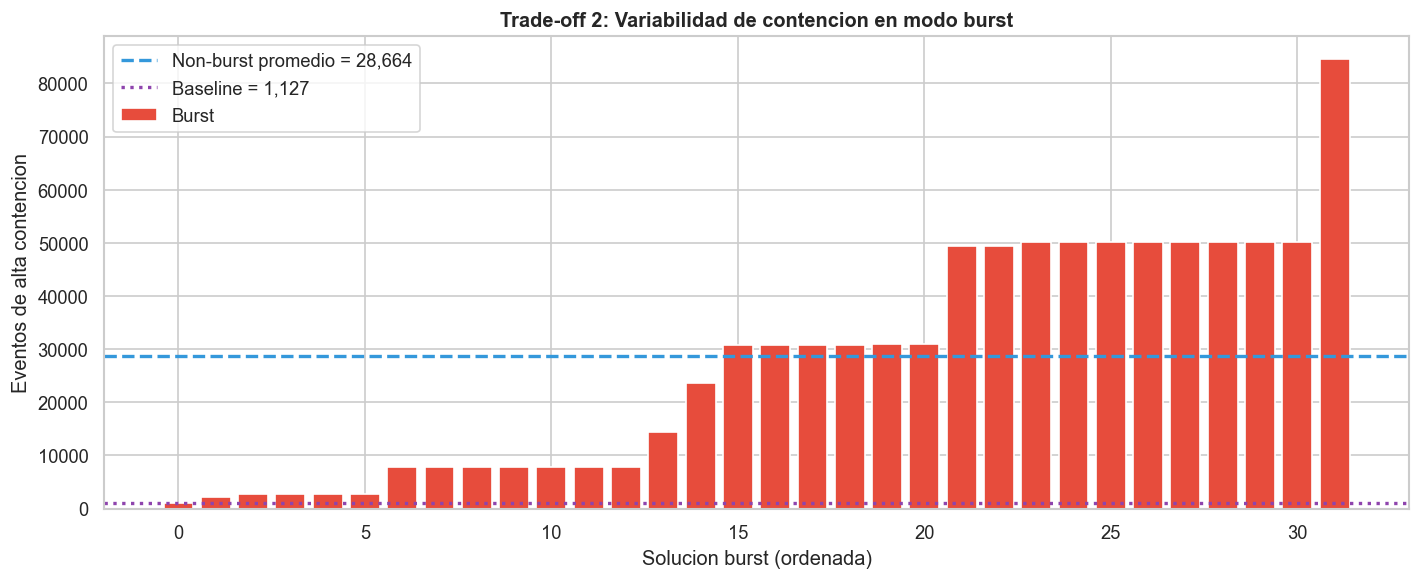

In [128]:
# --- Trade-off 2: Variabilidad de contencion ---

burst_df = pareto[pareto["scenario"] == "burst"].copy()
nonburst_df = pareto[pareto["scenario"] == "nonburst"].copy()

fig, ax = plt.subplots(figsize=(12, 5))

burst_sorted = burst_df.sort_values("high_contention_events").reset_index(drop=True)
ax.bar(range(len(burst_sorted)), burst_sorted["high_contention_events"],
       color=SCENARIO_COLORS["burst"], label="Burst", edgecolor="white")

if len(nonburst_df) > 0:
    nb_mean = nonburst_df["high_contention_events"].mean()
    ax.axhline(nb_mean, color=SCENARIO_COLORS["nonburst"], ls="--", lw=2,
               label=f"Non-burst promedio = {nb_mean:,.0f}")

bl_hc = baseline["high_contention_events"].iloc[0]
ax.axhline(bl_hc, color=SCENARIO_COLORS["baseline"], ls=":", lw=2,
           label=f"Baseline = {bl_hc:,}")

ax.set_xlabel("Solucion burst (ordenada)")
ax.set_ylabel("Eventos de alta contencion")
ax.set_title("Trade-off 2: Variabilidad de contencion en modo burst", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [129]:
# --- Interpretacion Trade-off 2 ---

cv_burst = burst_df["high_contention_events"].std() / burst_df["high_contention_events"].mean() if len(burst_df) > 1 else 0
cv_nonburst = nonburst_df["high_contention_events"].std() / nonburst_df["high_contention_events"].mean() if len(nonburst_df) > 1 else 0
bl_hc = baseline["high_contention_events"].iloc[0]

print("=" * 70)
print("TRADE-OFF 2: Predictibilidad operativa")
print("=" * 70)
print(f"\n  Contencion burst:     rango [{burst_df['high_contention_events'].min():,} - {burst_df['high_contention_events'].max():,}], CV = {cv_burst:.2f}")
print(f"  Contencion non-burst: rango [{nonburst_df['high_contention_events'].min():,} - {nonburst_df['high_contention_events'].max():,}], CV = {cv_nonburst:.2f}")
print(f"  Baseline:             {bl_hc:,} eventos")
print(f"\n  Burst tiene {cv_burst/cv_nonburst:.1f}x {'mas' if cv_burst > cv_nonburst else 'menos'} variabilidad que non-burst.")
print(f"\n  CONCLUSION:")
print(f"    La contencion varia enormemente entre soluciones burst ({burst_df['high_contention_events'].min():,} a {burst_df['high_contention_events'].max():,}).")
print(f"    Si se requiere predictibilidad operativa, el modo non-burst es preferible.")

TRADE-OFF 2: Predictibilidad operativa

  Contencion burst:     rango [977 - 84,667], CV = 0.81
  Contencion non-burst: rango [709 - 45,955], CV = 0.47
  Baseline:             1,127 eventos

  Burst tiene 1.7x mas variabilidad que non-burst.

  CONCLUSION:
    La contencion varia enormemente entre soluciones burst (977 a 84,667).
    Si se requiere predictibilidad operativa, el modo non-burst es preferible.


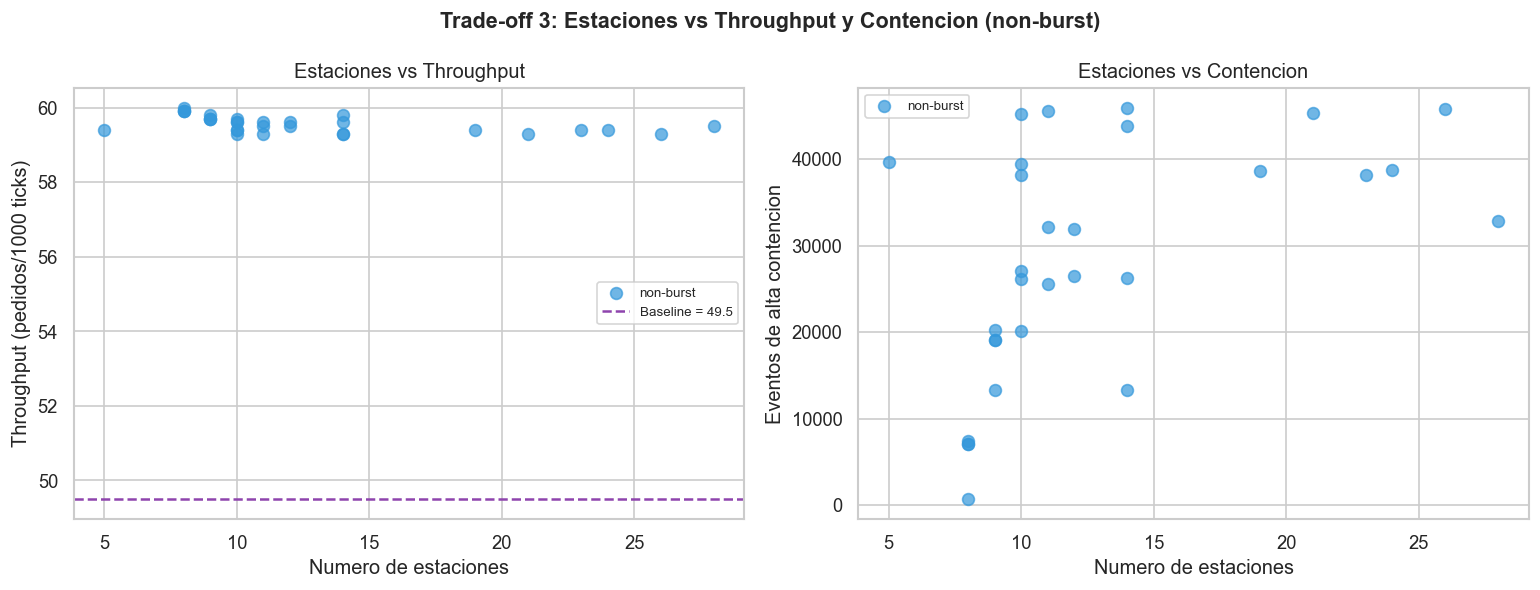

Correlacion Pearson (non-burst):
  Estaciones <-> Throughput:  r = -0.491 (moderada)
  Estaciones <-> Contencion: r = 0.490 (moderada)


In [130]:
# --- Trade-off 3: Estaciones vs Throughput ---

nb_all = pareto[pareto["scenario"] == "nonburst"].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(nb_all["stations"], nb_all["throughput_per_1000_ticks"],
            c=SCENARIO_COLORS["nonburst"], s=50, alpha=0.7, label="non-burst")
bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
ax1.axhline(bl_tp, color=SCENARIO_COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline = {bl_tp:.1f}")
ax1.set_xlabel("Numero de estaciones")
ax1.set_ylabel("Throughput (pedidos/1000 ticks)")
ax1.set_title("Estaciones vs Throughput")
ax1.legend(fontsize=8)

ax2.scatter(nb_all["stations"], nb_all["high_contention_events"],
            c=SCENARIO_COLORS["nonburst"], s=50, alpha=0.7, label="non-burst")
ax2.set_xlabel("Numero de estaciones")
ax2.set_ylabel("Eventos de alta contencion")
ax2.set_title("Estaciones vs Contencion")
ax2.legend(fontsize=8)

fig.suptitle("Trade-off 3: Estaciones vs Throughput y Contencion (non-burst)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlacion
r_tp, r_ct = np.nan, np.nan
if len(nb_all["stations"].unique()) > 1:
    r_tp = nb_all["stations"].corr(nb_all["throughput_per_1000_ticks"])
    r_ct = nb_all["stations"].corr(nb_all["high_contention_events"])
    print(f"Correlacion Pearson (non-burst):")
    print(f"  Estaciones <-> Throughput:  r = {r_tp:.3f} ({'debil' if abs(r_tp)<0.3 else 'moderada' if abs(r_tp)<0.7 else 'fuerte'})")
    print(f"  Estaciones <-> Contencion: r = {r_ct:.3f} ({'debil' if abs(r_ct)<0.3 else 'moderada' if abs(r_ct)<0.7 else 'fuerte'})")

In [131]:
# --- Interpretacion Trade-off 3 ---

bl_stations = int(baseline["stations"].iloc[0])
bl_cpo = baseline["contention_per_order"].iloc[0]
nb_cpo = nb_all["contention_per_order"].mean()

print("=" * 70)
print("TRADE-OFF 3: Estaciones vs Eficiencia")
print("=" * 70)
print(f"\n  Rango estaciones MOOP non-burst: {int(nb_all['stations'].min())}-{int(nb_all['stations'].max())}")
print(f"  Baseline: {bl_stations} estaciones")
print(f"\n  Contencion/pedido:")
print(f"    Non-burst MOOP: {nb_cpo:.2f}")
print(f"    Baseline:       {bl_cpo:.2f}")
delta_cpo = (nb_cpo / bl_cpo - 1) * 100 if bl_cpo != 0 else np.nan
print(f"    Cambio:         {delta_cpo:+.0f}%")
print(f"\n  CONCLUSION:")
if not np.isnan(r_tp):
    print(f"    La correlacion estaciones <-> throughput es {'debil' if abs(r_tp)<0.3 else 'moderada' if abs(r_tp)<0.7 else 'fuerte'} (r={r_tp:.3f}).")
print(f"    El optimizador encuentra un rango optimo; mas estaciones no siempre mejoran el throughput.")

TRADE-OFF 3: Estaciones vs Eficiencia

  Rango estaciones MOOP non-burst: 5-28
  Baseline: 20 estaciones

  Contencion/pedido:
    Non-burst MOOP: 48.21
    Baseline:       2.28
    Cambio:         +2017%

  CONCLUSION:
    La correlacion estaciones <-> throughput es moderada (r=-0.491).
    El optimizador encuentra un rango optimo; mas estaciones no siempre mejoran el throughput.


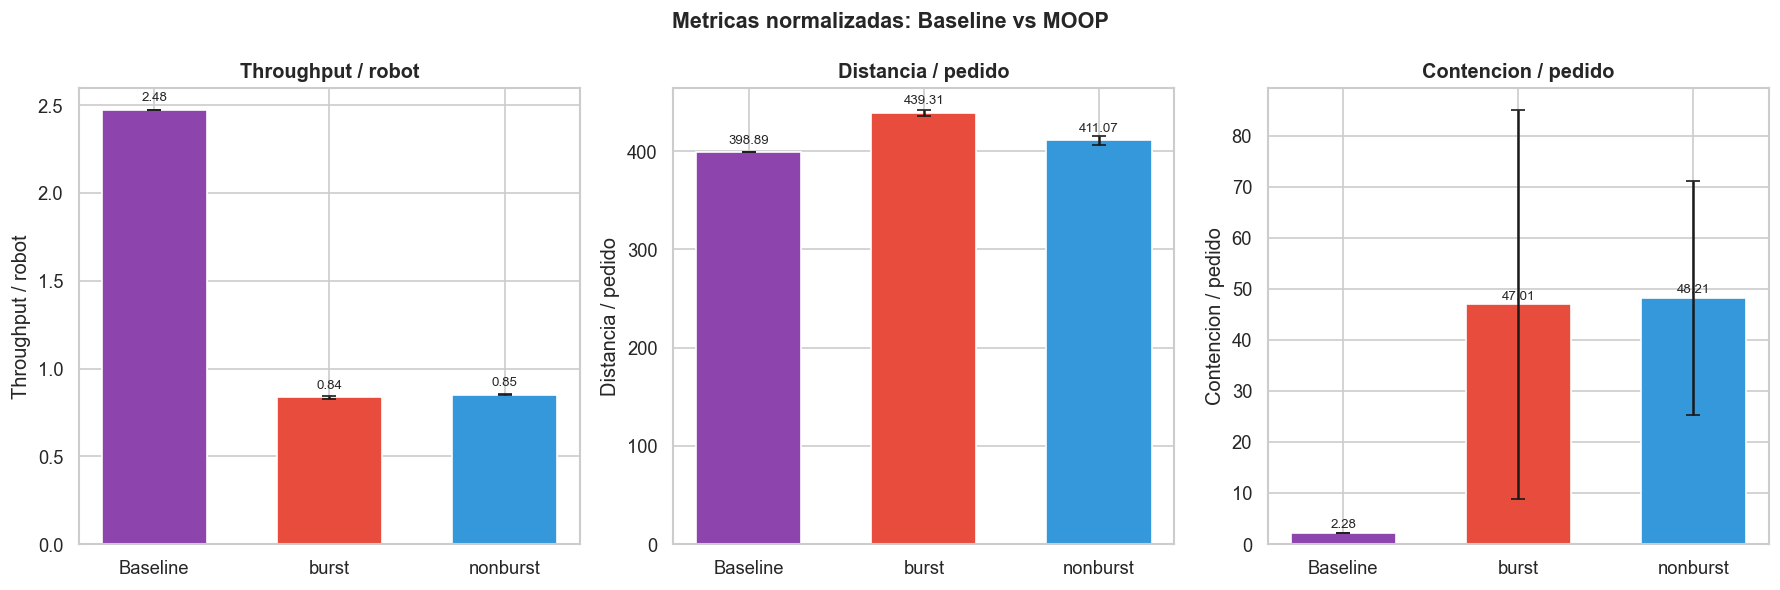

In [132]:
# --- Metricas de eficiencia normalizadas: Baseline vs MOOP ---

eff_metrics = [
    ("throughput_norm", "Throughput / robot"),
    ("distance_per_order", "Distancia / pedido"),
    ("contention_per_order", "Contencion / pedido"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, eff_metrics):
    bl_val = baseline[col].iloc[0]
    vals = [bl_val]
    errs = [0]
    labels = ["Baseline"]
    colors = [SCENARIO_COLORS["baseline"]]

    for scenario in SCENARIO_ORDER:
        s = pareto[pareto["scenario"] == scenario]
        vals.append(s[col].mean())
        errs.append(s[col].std() if len(s) > 1 else 0)
        labels.append(scenario)
        colors.append(SCENARIO_COLORS.get(scenario, "gray"))

    ax.bar(labels, vals, yerr=errs, color=colors, edgecolor="white",
           capsize=4, width=0.6)
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f"{v:.2f}", ha="center", fontsize=8)

fig.suptitle("Metricas normalizadas: Baseline vs MOOP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

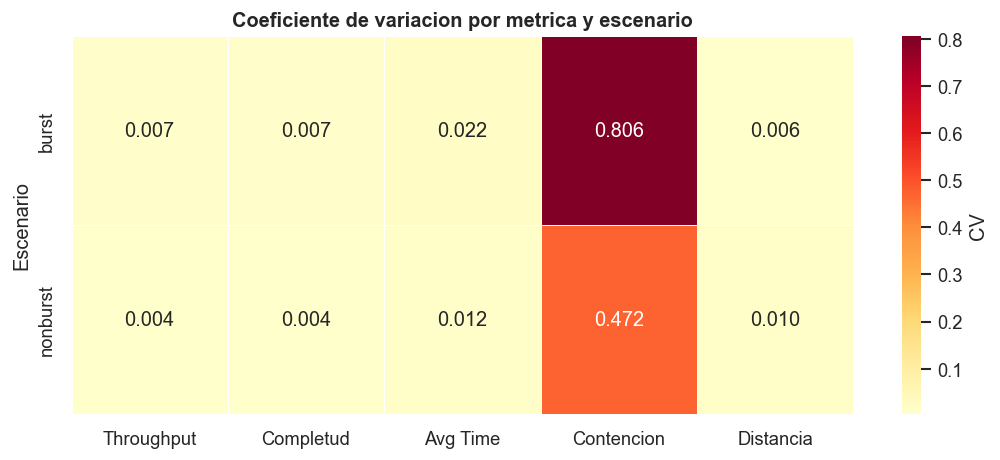

Interpretacion:
  burst: mayor variabilidad en Contencion (CV=0.806)
  nonburst: mayor variabilidad en Contencion (CV=0.472)


In [133]:
# --- Estabilidad: Heatmap de coeficiente de variacion ---

cv_cols = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "high_contention_events", "total_distance_cells",
]
cv_labels = ["Throughput", "Completud", "Avg Time", "Contencion", "Distancia"]

cv_data = []
for scenario in SCENARIO_ORDER:
    subset = pareto[pareto["scenario"] == scenario]
    row = {}
    for col, lbl in zip(cv_cols, cv_labels):
        mean = subset[col].mean()
        std = subset[col].std() if len(subset) > 1 else 0.0
        row[lbl] = std / mean if mean != 0 else 0.0
    cv_data.append(row)

cv_df = pd.DataFrame(cv_data, index=SCENARIO_ORDER)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(cv_df, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "CV"})
ax.set_title("Coeficiente de variacion por metrica y escenario", fontweight="bold")
ax.set_ylabel("Escenario")
plt.tight_layout()
plt.show()

print("Interpretacion:")
for scenario in SCENARIO_ORDER:
    worst_col = cv_df.loc[scenario].idxmax()
    worst_cv = cv_df.loc[scenario].max()
    print(f"  {scenario}: mayor variabilidad en {worst_col} (CV={worst_cv:.3f})")

In [134]:
# --- Robustez: analisis de deadlocks ---

dl_by_scenario = pareto.groupby("scenario")["deadlocks"].agg(["mean", "std", "min", "max", "count"])
display(dl_by_scenario)

bl_dl = int(baseline["deadlocks"].iloc[0])
print(f"\nBaseline deadlocks: {bl_dl:,}")

for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    n_with_dl = (s["deadlocks"] > 0).sum()
    n_total = len(s)
    print(f"\n  {scenario} ({n_total} soluciones):")
    print(f"    Con deadlocks: {n_with_dl}/{n_total} ({n_with_dl/n_total*100:.0f}%)")
    print(f"    Deadlocks promedio: {s['deadlocks'].mean():,.0f}")
    if n_with_dl > 0 and n_with_dl < n_total:
        with_dl = s[s["deadlocks"] > 0]
        without_dl = s[s["deadlocks"] == 0]
        tp_with = with_dl["throughput_per_1000_ticks"].mean()
        tp_without = without_dl["throughput_per_1000_ticks"].mean()
        print(f"    Throughput con DL: {tp_with:.1f} vs sin DL: {tp_without:.1f} (delta={tp_with-tp_without:+.1f})")

if pareto["deadlocks"].std() > 0:
    r = pareto["deadlocks"].corr(pareto["throughput_per_1000_ticks"])
    print(f"\n  Pearson deadlocks <-> throughput: r = {r:.3f} ({'debil' if abs(r)<0.3 else 'moderada' if abs(r)<0.7 else 'fuerte'})")

print(f"\n  CONCLUSION:")
print(f"    El baseline tiene {bl_dl:,} deadlocks vs MOOP 0-{int(pareto['deadlocks'].max()):,}.")
if bl_dl == 0:
    print(f"    Baseline opera sin deadlocks gracias a su menor densidad ({int(baseline['robots'].iloc[0])} robots en grid grande).")
    print(f"    MOOP non-burst genera deadlocks por operar con mas robots en area fija, pero mantiene throughput alto.")
else:
    print(f"    MOOP reduce deadlocks en burst (0 deadlocks) y los mantiene similares en non-burst.")

,mean,std,min,max,count
scenario,,,,,
burst,0.000000,0.000000,0,0,32
nonburst,5577.533333,1062.154438,0,6207,30



Baseline deadlocks: 0

  burst (32 soluciones):
    Con deadlocks: 0/32 (0%)
    Deadlocks promedio: 0

  nonburst (30 soluciones):
    Con deadlocks: 29/30 (97%)
    Deadlocks promedio: 5,578
    Throughput con DL: 59.5 vs sin DL: 60.0 (delta=-0.5)

  Pearson deadlocks <-> throughput: r = 0.789 (fuerte)

  CONCLUSION:
    El baseline tiene 0 deadlocks vs MOOP 0-6,207.
    Baseline opera sin deadlocks gracias a su menor densidad (20 robots en grid grande).
    MOOP non-burst genera deadlocks por operar con mas robots en area fija, pero mantiene throughput alto.


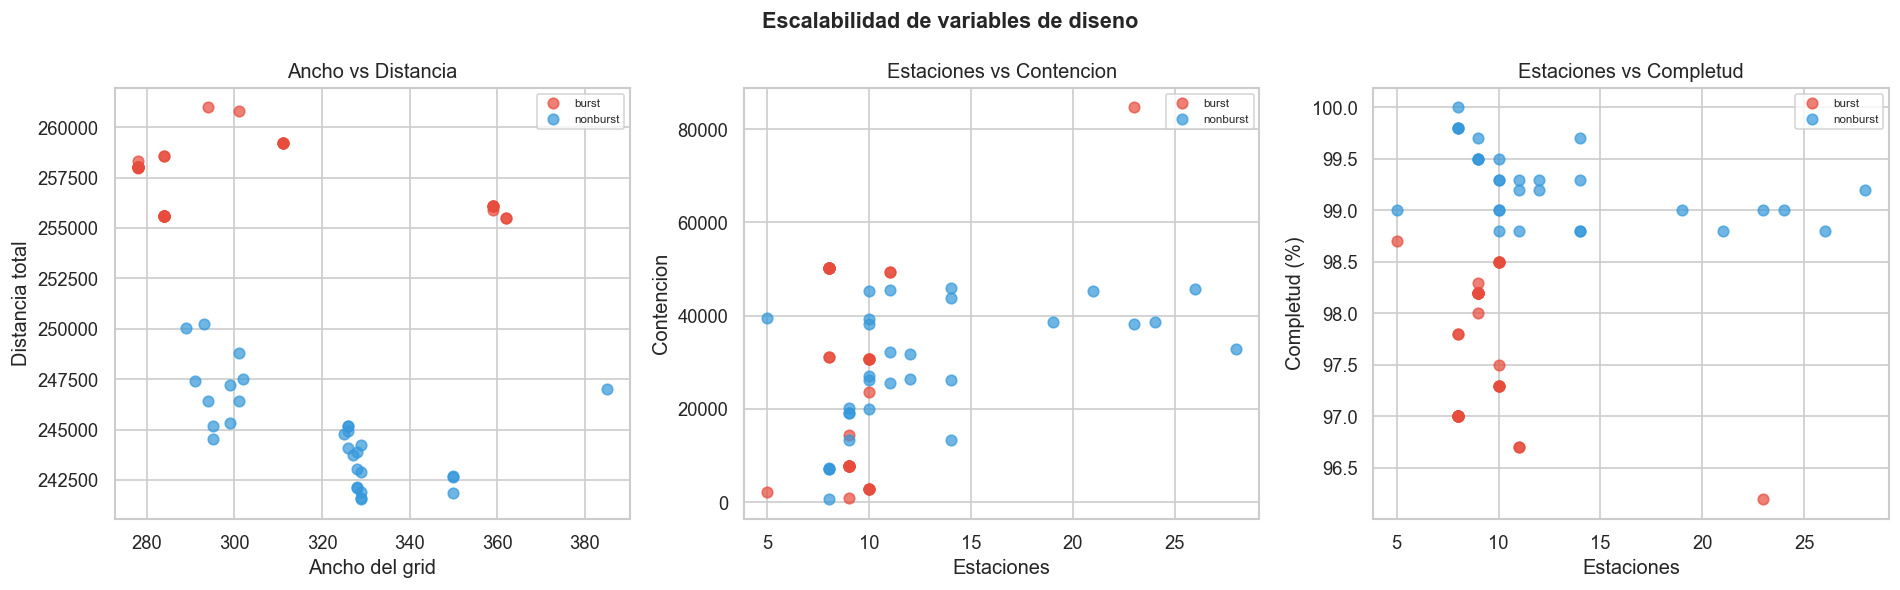

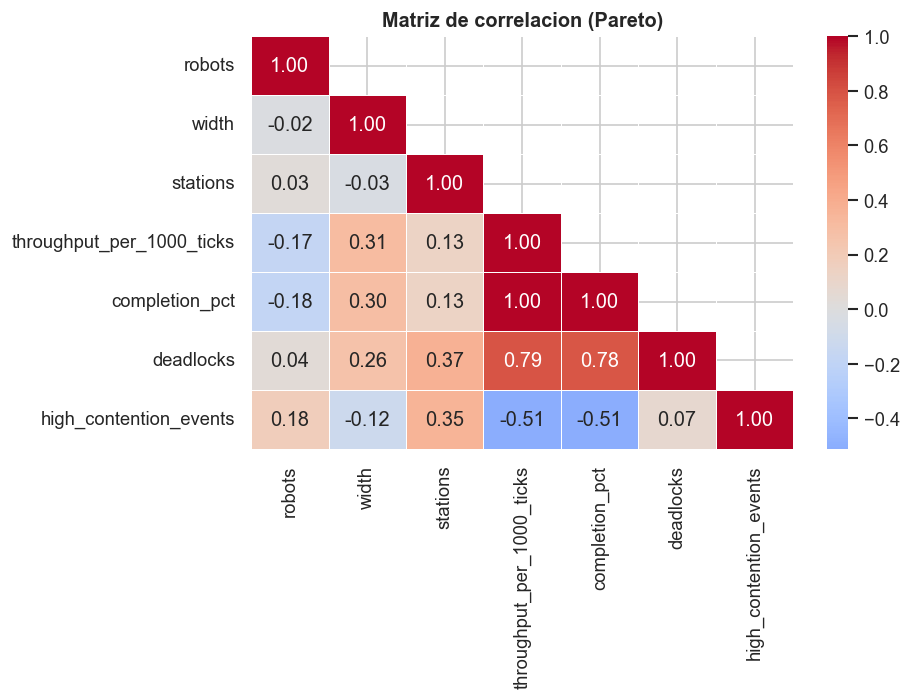

In [135]:
# --- Escalabilidad ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    c = SCENARIO_COLORS.get(scenario, "gray")
    axes[0].scatter(s["width"], s["total_distance_cells"], c=c, label=scenario, s=40, alpha=0.7)
    axes[1].scatter(s["stations"], s["high_contention_events"], c=c, label=scenario, s=40, alpha=0.7)
    axes[2].scatter(s["stations"], s["completion_pct"], c=c, label=scenario, s=40, alpha=0.7)

axes[0].set_xlabel("Ancho del grid")
axes[0].set_ylabel("Distancia total")
axes[0].set_title("Ancho vs Distancia")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("Estaciones")
axes[1].set_ylabel("Contencion")
axes[1].set_title("Estaciones vs Contencion")
axes[1].legend(fontsize=7)

axes[2].set_xlabel("Estaciones")
axes[2].set_ylabel("Completud (%)")
axes[2].set_title("Estaciones vs Completud")
axes[2].legend(fontsize=7)

fig.suptitle("Escalabilidad de variables de diseno", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Matriz de correlacion
corr_cols = ["robots", "width", "stations", "throughput_per_1000_ticks",
             "completion_pct", "deadlocks", "high_contention_events"]
corr = pareto[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
            center=0, linewidths=0.5)
ax.set_title("Matriz de correlacion (Pareto)", fontweight="bold")
plt.tight_layout()
plt.show()

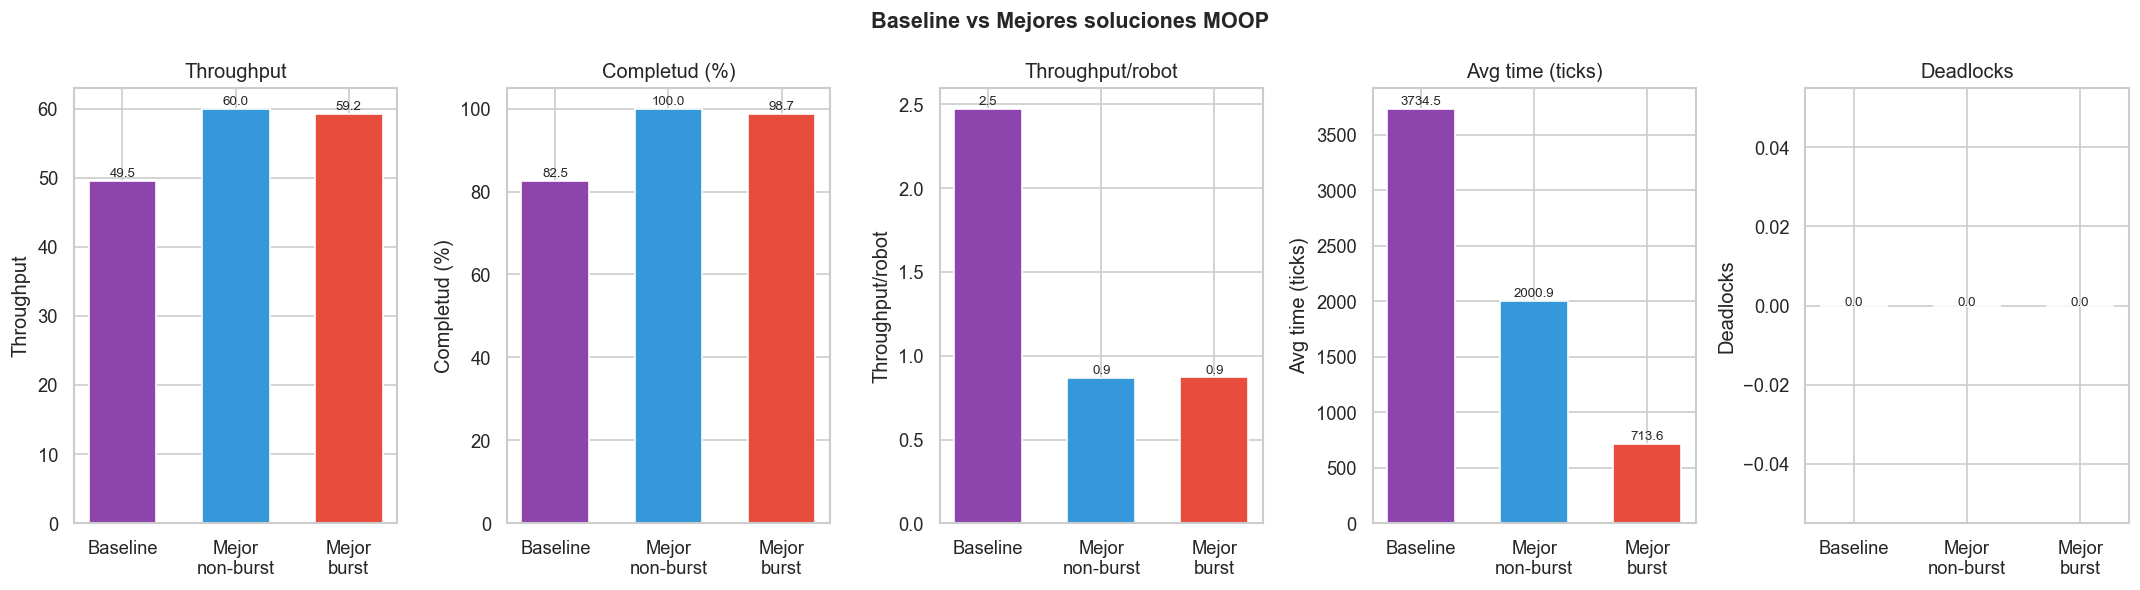

In [136]:
# --- Comparacion directa: Baseline vs Mejor MOOP ---

best_nb = pareto[pareto["scenario"] == "nonburst"]
best_nb_row = best_nb.loc[best_nb["throughput_per_1000_ticks"].idxmax()] if len(best_nb) > 0 else None

best_burst = pareto[pareto["scenario"] == "burst"]
best_burst_row = best_burst.loc[best_burst["throughput_per_1000_ticks"].idxmax()] if len(best_burst) > 0 else None

comp_metrics = ["throughput_per_1000_ticks", "completion_pct", "throughput_norm",
                "avg_order_time_ticks", "deadlocks"]
comp_labels = ["Throughput", "Completud (%)", "Throughput/robot", "Avg time (ticks)", "Deadlocks"]

fig, axes = plt.subplots(1, len(comp_metrics), figsize=(18, 5))

for ax, col, label in zip(axes, comp_metrics, comp_labels):
    vals = [baseline[col].iloc[0]]
    bar_labels = ["Baseline"]
    bar_colors = [SCENARIO_COLORS["baseline"]]

    if best_nb_row is not None:
        vals.append(best_nb_row[col])
        bar_labels.append("Mejor\nnon-burst")
        bar_colors.append(SCENARIO_COLORS["nonburst"])

    if best_burst_row is not None:
        vals.append(best_burst_row[col])
        bar_labels.append("Mejor\nburst")
        bar_colors.append(SCENARIO_COLORS["burst"])

    ax.bar(bar_labels, vals, color=bar_colors, edgecolor="white", width=0.6)
    ax.set_ylabel(label)
    ax.set_title(label)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.01, f"{v:.1f}", ha="center", fontsize=8)

fig.suptitle("Baseline vs Mejores soluciones MOOP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [137]:
# --- Tabla de deltas: Mejor MOOP vs Baseline ---

all_compare = [
    "throughput_per_1000_ticks", "completion_pct", "avg_order_time_ticks",
    "deadlocks", "high_contention_events", "total_distance_cells",
    "throughput_norm", "distance_per_order", "contention_per_order",
]
all_labels = [
    "Throughput", "Completud %", "Avg time (ticks)",
    "Deadlocks", "Contencion", "Distancia total",
    "Throughput/robot", "Distancia/pedido", "Contencion/pedido",
]

delta_data = {
    "Metrica": all_labels,
    "Baseline": [baseline[c].iloc[0] for c in all_compare],
}
if best_nb_row is not None:
    delta_data["Mejor non-burst"] = [best_nb_row[c] for c in all_compare]
if best_burst_row is not None:
    delta_data["Mejor burst"] = [best_burst_row[c] for c in all_compare]

delta_detail = pd.DataFrame(delta_data)

if best_nb_row is not None:
    delta_detail["Delta% non-burst"] = (
        (delta_detail["Mejor non-burst"] - delta_detail["Baseline"])
        / delta_detail["Baseline"].replace(0, np.nan) * 100
    ).round(1)

if best_burst_row is not None:
    delta_detail["Delta% burst"] = (
        (delta_detail["Mejor burst"] - delta_detail["Baseline"])
        / delta_detail["Baseline"].replace(0, np.nan) * 100
    ).round(1)

display(delta_detail.set_index("Metrica"))

print(f"\nBaseline: {int(baseline['robots'].iloc[0])} robots, grid {int(baseline['width'].iloc[0])}x{int(baseline['height'].iloc[0])}")
if best_nb_row is not None:
    print(f"Mejor non-burst: {int(best_nb_row['robots'])} robots, grid {int(best_nb_row['width'])}x{int(best_nb_row['height'])}")
if best_burst_row is not None:
    print(f"Mejor burst: {int(best_burst_row['robots'])} robots, grid {int(best_burst_row['width'])}x{int(best_burst_row['height'])}")

,Baseline,Mejor non-burst,Mejor burst,Delta% non-burst,Delta% burst
Metrica,,,,,
Throughput,49.500000,60.000000,59.200000,21.2,19.6
Completud %,82.500000,100.000000,98.700000,21.2,19.6
Avg time (ticks),3734.486869,2000.900000,713.600000,-46.4,-80.9
Deadlocks,0.000000,0.000000,0.000000,NaN,NaN
Contencion,1127.000000,709.000000,2108.000000,-37.1,87.0
Distancia total,197449.000000,242704.000000,260987.000000,22.9,32.2
Throughput/robot,2.475000,0.869565,0.870588,-64.9,-64.8
Distancia/pedido,398.886869,404.506667,440.856419,1.4,10.5
Contencion/pedido,2.276768,1.181667,3.560811,-48.1,56.4



Baseline: 20 robots, grid 300x200
Mejor non-burst: 69 robots, grid 350x171
Mejor burst: 68 robots, grid 294x204


In [138]:
# --- Que cambio vs Baseline ---

print("=" * 70)
print("QUE CAMBIO: BASELINE vs MOOP")
print("=" * 70)

diff_table = pd.DataFrame({
    "Aspecto": ["Robots", "Grid", "Estaciones", "Burst", "Ticks",
                "Throughput", "Completud", "Deadlocks", "Contencion",
                "Throughput/robot", "Contencion/pedido"],
    "Baseline": [
        int(baseline["robots"].iloc[0]),
        f"{int(baseline['width'].iloc[0])}x{int(baseline['height'].iloc[0])}",
        int(baseline["stations"].iloc[0]),
        str(baseline["orders_burst"].iloc[0]),
        int(baseline["final_tick"].iloc[0]),
        f"{baseline['throughput_per_1000_ticks'].iloc[0]:.1f}",
        f"{baseline['completion_pct'].iloc[0]:.1f}%",
        f"{int(baseline['deadlocks'].iloc[0]):,}",
        f"{int(baseline['high_contention_events'].iloc[0]):,}",
        f"{baseline['throughput_norm'].iloc[0]:.3f}",
        f"{baseline['contention_per_order'].iloc[0]:.2f}",
    ],
    "MOOP (promedio)": [
        f"{int(pareto['robots'].min())}-{int(pareto['robots'].max())}",
        f"Area=60,000 ({int(pareto['width'].min())}-{int(pareto['width'].max())} ancho)",
        f"{int(pareto['stations'].min())}-{int(pareto['stations'].max())}",
        f"Burst: {(pareto['orders_burst']==True).sum()}, Non-burst: {(pareto['orders_burst']==False).sum()}",
        "10,000",
        f"{pareto['throughput_per_1000_ticks'].mean():.1f}",
        f"{pareto['completion_pct'].mean():.1f}%",
        f"{pareto['deadlocks'].mean():,.0f} ({int(pareto['deadlocks'].min())}-{int(pareto['deadlocks'].max())})",
        f"{pareto['high_contention_events'].mean():,.0f}",
        f"{pareto['throughput_norm'].mean():.3f}",
        f"{pareto['contention_per_order'].mean():.2f}",
    ],
})
display(diff_table.set_index("Aspecto"))

# Lo que aprendio el optimizador
print("\n" + "=" * 70)
print("LO QUE APRENDIO EL OPTIMIZADOR")
print("=" * 70)

robot_val = int(pareto["robots"].mode().iloc[0])
bl_robots = int(baseline["robots"].iloc[0])
print(f"\n1. CONVERGENCIA DE ROBOTS:")
print(f"   {pareto['robots'].nunique()} valor(es) unico(s), converge a ~{robot_val} robots")
print(f"   Baseline: {bl_robots} robots")
print(f"   -> {robot_val/bl_robots:.1f}x mas robots mejoran throughput absoluto")

print(f"\n2. PREFERENCIA DE GRID:")
print(f"   Anchos MOOP: {sorted(pareto['width'].unique())}")
print(f"   Ratio ancho/alto promedio: {pareto['width'].mean()/pareto['height'].mean():.1f}:1")
print(f"   Baseline: {int(baseline['width'].iloc[0])}x{int(baseline['height'].iloc[0])} (ratio {baseline['width'].iloc[0]/baseline['height'].iloc[0]:.1f}:1)")

st_mode = int(pareto["stations"].mode().iloc[0])
print(f"\n3. RANGO OPTIMO DE ESTACIONES:")
print(f"   MOOP: {int(pareto['stations'].min())}-{int(pareto['stations'].max())}, moda: {st_mode}")
print(f"   Baseline: {int(baseline['stations'].iloc[0])} estaciones")

print(f"\n4. DOS REGIMENES OPERATIVOS:")
for scenario in SCENARIO_ORDER:
    s = pareto[pareto["scenario"] == scenario]
    print(f"   {scenario}: n={len(s)}, tp={s['throughput_per_1000_ticks'].mean():.1f}, "
          f"comp={s['completion_pct'].mean():.1f}%, time={s['avg_order_time_ticks'].mean():.0f}")
print(f"   Baseline: tp={baseline['throughput_per_1000_ticks'].iloc[0]:.1f}, "
      f"comp={baseline['completion_pct'].iloc[0]:.1f}%, time={baseline['avg_order_time_ticks'].iloc[0]:.0f}")

QUE CAMBIO: BASELINE vs MOOP


,Baseline,MOOP (promedio)
Aspecto,,
Robots,20,68-70
Grid,300x200,"Area=60,000 (278-385 ancho)"
Estaciones,20,5-28
Burst,True,"Burst: 32, Non-burst: 30"
Ticks,10000,"10,000"
Throughput,49.5,59.1
Completud,82.5%,98.4%
Deadlocks,0,"2,699 (0-6207)"
Contencion,"1,127","28,008"



LO QUE APRENDIO EL OPTIMIZADOR

1. CONVERGENCIA DE ROBOTS:
   3 valor(es) unico(s), converge a ~70 robots
   Baseline: 20 robots
   -> 3.5x mas robots mejoran throughput absoluto

2. PREFERENCIA DE GRID:
   Anchos MOOP: [278, 284, 289, 291, 293, 294, 295, 299, 301, 302, 311, 325, 326, 327, 328, 329, 350, 359, 362, 385]
   Ratio ancho/alto promedio: 1.6:1
   Baseline: 300x200 (ratio 1.5:1)

3. RANGO OPTIMO DE ESTACIONES:
   MOOP: 5-28, moda: 10
   Baseline: 20 estaciones

4. DOS REGIMENES OPERATIVOS:
   burst: n=32, tp=58.6, comp=97.6%, time=657
   nonburst: n=30, tp=59.6, comp=99.3%, time=1963
   Baseline: tp=49.5, comp=82.5%, time=3734


In [139]:
# --- Conclusiones ---

bl_tp = baseline["throughput_per_1000_ticks"].iloc[0]
bl_cp = baseline["completion_pct"].iloc[0]
bl_at = baseline["avg_order_time_ticks"].iloc[0]
bl_dl = int(baseline["deadlocks"].iloc[0])
bl_hc = int(baseline["high_contention_events"].iloc[0])
bl_tn = baseline["throughput_norm"].iloc[0]
bl_robots = int(baseline["robots"].iloc[0])

burst_s = pareto[pareto["scenario"] == "burst"]
nb_s = pareto[pareto["scenario"] == "nonburst"]
robot_val = int(pareto["robots"].mode().iloc[0])

burst_tp = burst_s["throughput_per_1000_ticks"].mean()
nb_tp = nb_s["throughput_per_1000_ticks"].mean()
burst_cp = burst_s["completion_pct"].mean()
nb_cp = nb_s["completion_pct"].mean()
burst_at = burst_s["avg_order_time_ticks"].mean()
nb_at = nb_s["avg_order_time_ticks"].mean()
nb_tn = nb_s["throughput_norm"].mean()
burst_tn = burst_s["throughput_norm"].mean()

print("=" * 70)
print("CONCLUSIONES")
print("=" * 70)

print(f"""
1. MEJORA EN THROUGHPUT
   Baseline: {bl_tp:.1f} pedidos/1000t (con {bl_robots} robots)
   MOOP non-burst: {nb_tp:.1f} pedidos/1000t (con ~{robot_val} robots)
   MOOP burst: {burst_tp:.1f} pedidos/1000t
   -> MOOP supera al baseline en throughput absoluto ({(nb_tp/bl_tp-1)*100:+.1f}% non-burst)
   -> En throughput/robot: baseline={bl_tn:.3f} vs MOOP={nb_tn:.3f} ({(nb_tn/bl_tn-1)*100:+.1f}%)

2. CONVERGENCIA DE ROBOTS
   El NSGA-II converge a ~{robot_val} robots (de {bl_robots} en baseline).
   Mas robots permiten mayor throughput y menor tiempo por pedido.

3. DOS REGIMENES OPERATIVOS
   Burst ({len(burst_s)} sol.): ~{burst_at:,.0f} ticks/pedido, {burst_cp:.1f}% completud
   Non-burst ({len(nb_s)} sol.): ~{nb_at:,.0f} ticks/pedido, {nb_cp:.1f}% completud
   Baseline: {bl_at:,.0f} ticks/pedido, {bl_cp:.1f}% completud

4. TRADE-OFF PRINCIPAL: VELOCIDAD vs COMPLETUD
   Burst reduce tiempo en {(1-burst_at/nb_at)*100:.0f}% vs non-burst,
   pero pierde ~{nb_cp-burst_cp:.0f}pp de completud.
   Ambos mejoran vs baseline ({bl_at:,.0f} ticks).

5. DEADLOCKS Y ROBUSTEZ
   Baseline: {bl_dl:,} deadlocks
   MOOP burst: 0 deadlocks (modo rafaga evita congestion prolongada)
   MOOP non-burst: {nb_s['deadlocks'].mean():,.0f} promedio (densidad mayor genera friccion)
   El sistema absorbe deadlocks sin degradar throughput significativamente.

6. ESCALABILIDAD DE ESTACIONES
   Rango optimo MOOP: {int(pareto['stations'].min())}-{int(pareto['stations'].max())} estaciones.
   Baseline usa {int(baseline['stations'].iloc[0])}.
   Mas estaciones no siempre mejoran throughput; el optimizador encuentra el balance.
""")

CONCLUSIONES

1. MEJORA EN THROUGHPUT
   Baseline: 49.5 pedidos/1000t (con 20 robots)
   MOOP non-burst: 59.6 pedidos/1000t (con ~70 robots)
   MOOP burst: 58.6 pedidos/1000t
   -> MOOP supera al baseline en throughput absoluto (+20.3% non-burst)
   -> En throughput/robot: baseline=2.475 vs MOOP=0.852 (-65.6%)

2. CONVERGENCIA DE ROBOTS
   El NSGA-II converge a ~70 robots (de 20 en baseline).
   Mas robots permiten mayor throughput y menor tiempo por pedido.

3. DOS REGIMENES OPERATIVOS
   Burst (32 sol.): ~657 ticks/pedido, 97.6% completud
   Non-burst (30 sol.): ~1,963 ticks/pedido, 99.3% completud
   Baseline: 3,734 ticks/pedido, 82.5% completud

4. TRADE-OFF PRINCIPAL: VELOCIDAD vs COMPLETUD
   Burst reduce tiempo en 67% vs non-burst,
   pero pierde ~2pp de completud.
   Ambos mejoran vs baseline (3,734 ticks).

5. DEADLOCKS Y ROBUSTEZ
   Baseline: 0 deadlocks
   MOOP burst: 0 deadlocks (modo rafaga evita congestion prolongada)
   MOOP non-burst: 5,578 promedio (densidad mayor gene